# FinSight — Financial Document Intelligence Engine
**Multi-Modal Retrieval + Agentic Risk Analysis**

### Functions
1. Installs ColPali (visual document retrieval) and Qwen2-VL-7B-Instruct (vision-language model)
2. Builds the ColPali indexer — converts PDF pages to image embeddings
3. Implements the Qwen2-VL extraction pipeline — structured JSON from financial pages
4. Builds the agentic risk analysis loop
5. Tests end-to-end on real SEC EDGAR filings
6. Saves all components for Hugging Face Spaces deployment

**Kaggle setup done:**
- Accelerator: GPU T4 x2
- Internet: ON
- Persistent storage: ON
- Add HuggingFace token as Kaggle secret named `HF_TOKEN`

In [ ]:
# 1: Installing dependencies + compatibility check
import os
import numpy as np
from importlib import reload

current_np = np.__version__
print(f"Startup NumPy version: {current_np}")

if not current_np.startswith("1.26"):
    print("--- INCOMPATIBLE NUMPY DETECTED. FIXING... ---")
    # Forcing the correct version
    !pip uninstall -y numpy
    !pip install -q "numpy==1.26.4"
    !pip install -q "transformers>=4.46.3" "accelerate>=0.30.0" "bitsandbytes" "colpali-engine>=0.3.1"
    !pip install -q pymupdf pillow sentencepiece protobuf
    
    print("\n!!! RESTARTING TO APPLY FIX !!!")
    os._exit(0) 
else:
    print("--- ENVIRONMENT OK: NumPy 1.26.4 is active. Proceeding... ---")

!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118

Startup NumPy version: 2.0.2
--- INCOMPATIBLE NUMPY DETECTED. FIXING... ---
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is inc

In [1]:
# numpy verification
import numpy as np

current_np = np.__version__
print(f"Startup NumPy version: {current_np}")

Startup NumPy version: 1.26.4


In [2]:
# 2: HuggingFace login
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

token = UserSecretsClient().get_secret('HF_TOKEN_FS')
login(token=token)
print('HuggingFace login successful.')

HuggingFace login successful.


In [3]:
# 3: Download real SEC EDGAR filings
# Uses SEC EDGAR's stable EDGAR Full-Text Search API and direct filing archives.

import os
import requests
import time

os.makedirs('/kaggle/working/docs', exist_ok=True)

HEADERS = {
    'User-Agent': 'FinSight Research muhammadfahadhassan01@gmail.com',
    'Accept-Encoding': 'gzip, deflate',
    'Host': 'www.sec.gov'
}

def get_latest_10k_url(cik: str) -> str:
    """
    Use SEC EDGAR company facts API to find the latest 10-K filing URL.
    CIK = Central Index Key (every public company has one, permanent).
    """
    cik_padded = cik.zfill(10)
    
    url = f'https://data.sec.gov/submissions/CIK{cik_padded}.json'
    r = requests.get(url, headers=HEADERS, timeout=15)
    r.raise_for_status()
    data = r.json()
    
    recent = data['filings']['recent']
    forms  = recent['form']
    dates  = recent['filingDate']
    accessions = recent['accessionNumber']
    
    for form, date, acc in zip(forms, dates, accessions):
        if form == '10-K':
            acc_clean = acc.replace('-', '')
            base_url = f'https://www.sec.gov/Archives/edgar/data/{cik}/{acc_clean}'
            idx_url = f'{base_url}/{acc}-index.json'
            idx_r = requests.get(idx_url, headers=HEADERS, timeout=15)
            if idx_r.status_code == 200:
                idx = idx_r.json()
                for doc in idx.get('documents', []):
                    if doc.get('type') == '10-K' and doc['name'].endswith('.htm'):
                        return f'{base_url}/{doc["name"]}', date
            return None, date
    return None, None

def download_sec_filing_as_pdf(cik: str, company: str, filename: str) -> bool:
    """
    Download a 10-K filing from SEC EDGAR and save as PDF using weasyprint.
    The .htm file is the complete, official filing.
    """
    print(f' Fetching {company} (CIK: {cik})...')
    
    try:
        filing_url, filing_date = get_latest_10k_url(cik)
        if not filing_url:
            print(f'  No 10-K found for {company}')
            return False
        
        print(f'  Filing date: {filing_date}')
        print(f'  URL: {filing_url}')
        
        r = requests.get(filing_url, headers=HEADERS, timeout=60)
        r.raise_for_status()
        
        html_path = f'/kaggle/working/docs/{filename}.htm'
        with open(html_path, 'wb') as f:
            f.write(r.content)
        print(f'  Downloaded HTML: {len(r.content)/1024:.0f} KB')
        
        import subprocess
        pdf_path = f'/kaggle/working/docs/{filename}.pdf'
        result = subprocess.run(
            ['weasyprint', html_path, pdf_path],
            capture_output=True, text=True, timeout=120
        )
        
        if os.path.exists(pdf_path) and os.path.getsize(pdf_path) > 5000:
            print(f'  Converted to PDF: {os.path.getsize(pdf_path)/1024:.0f} KB → {pdf_path}')
            os.remove(html_path)  
            return True
        else:
            print('  weasyprint conversion issue — trying pdfkit...')
            result2 = subprocess.run(
                ['pip', 'install', '-q', 'pdfkit'],
                capture_output=True
            )
            import pdfkit
            pdfkit.from_file(html_path, pdf_path)
            if os.path.exists(pdf_path) and os.path.getsize(pdf_path) > 5000:
                print(f'  PDF created: {os.path.getsize(pdf_path)/1024:.0f} KB')
                os.remove(html_path)
                return True
            return False
            
    except Exception as e:
        print(f'  Error: {e}')
        return False

def download_direct_pdf(url: str, filename: str, label: str) -> bool:
    """
    Download a PDF directly from a stable SEC Archives URL.
    """
    print(f' Downloading {label}...')
    try:
        r = requests.get(url, headers=HEADERS, timeout=60)
        if r.status_code == 200 and len(r.content) > 10000:
            path = f'/kaggle/working/docs/{filename}'
            with open(path, 'wb') as f:
                f.write(r.content)
            print(f'  ✓ {filename}: {len(r.content)/1024:.0f} KB')
            return True
        else:
            print(f'  ✗ Status {r.status_code}')
            return False
    except Exception as e:
        print(f'  ✗ Error: {e}')
        return False



FILINGS = [
    {
        'label': 'Apple Inc. — 10-K FY2023 (Annual Report)',
        'filename': 'apple_10k_2023.pdf',
        'url': 'https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm'
    },
    {
        'label': 'Microsoft Corp. — 10-K FY2024 (Annual Report)',
        'filename': 'microsoft_10k_2024.pdf',
        'url': 'https://www.sec.gov/Archives/edgar/data/789019/000095017024087843/msft-20240630.htm'
    },
    {
        'label': 'JPMorgan Chase — 10-K FY2023 (Annual Report)',
        'filename': 'jpmorgan_10k_2023.pdf',
        'url': 'https://www.sec.gov/Archives/edgar/data/70858/000007085824000038/jpm-20231231.htm'
    },
]

import subprocess
print('Installing PDF conversion tools...')
subprocess.run(['pip', 'install', '-q', 'weasyprint'], capture_output=True)

downloaded = []
for filing in FILINGS:
    print(f' {filing["label"]}')
    try:
        r = requests.get(filing['url'], headers=HEADERS, timeout=60)
        if r.status_code != 200:
            print(f'  ✗ HTTP {r.status_code} — skipping')
            continue
        
        html_path = f'/kaggle/working/docs/_{filing["filename"]}.htm'
        with open(html_path, 'wb') as f:
            f.write(r.content)
        print(f'  Downloaded HTML: {len(r.content)/1024:.0f} KB')
        
        pdf_path = f'/kaggle/working/docs/{filing["filename"]}' 
        conv = subprocess.run(
            ['weasyprint', html_path, pdf_path],
            capture_output=True, text=True, timeout=180
        )
        
        if os.path.exists(pdf_path) and os.path.getsize(pdf_path) > 10000:
            size_mb = os.path.getsize(pdf_path) / (1024*1024)
            print(f'  ✓ PDF: {size_mb:.1f} MB → {filing["filename"]}')
            os.remove(html_path)
            downloaded.append(filing['filename'])
        else:
            print(f'  ✗ PDF conversion failed (weasyprint stderr: {conv.stderr[:200]})')
            os.rename(html_path, html_path.replace('._', '').replace('.htm', '_raw.htm'))
            
    except Exception as e:
        print(f'  ✗ {e}')
    
    time.sleep(1) 

print(''+ '='*50)
print('Available documents:')
for f in sorted(os.listdir('/kaggle/working/docs')):
    size = os.path.getsize(f'/kaggle/working/docs/{f}')
    status = '✓' if size > 10000 else '?'
    print(f'  {status} {f}: {size/1024:.1f} KB')

if not downloaded:
    print('⚠ No PDFs downloaded. Check network access and try running the cell again.')
    print('If the issue persists, go to Notebook Settings and ensure Internet is ON.')
else:
    print(f'✓ {len(downloaded)} filing(s) ready for FinSight pipeline.')

DOC_PATH = f'/kaggle/working/docs/{downloaded[0]}' if downloaded else None
print(f'Primary document: {DOC_PATH}')

Installing PDF conversion tools...
 Apple Inc. — 10-K FY2023 (Annual Report)
  Downloaded HTML: 1522 KB
  ✓ PDF: 0.4 MB → apple_10k_2023.pdf
 Microsoft Corp. — 10-K FY2024 (Annual Report)
  Downloaded HTML: 6700 KB
  ✓ PDF: 0.7 MB → microsoft_10k_2024.pdf
 JPMorgan Chase — 10-K FY2023 (Annual Report)
  ✗ HTTP 404 — skipping
Available documents:
  ✓ apple_10k_2023.pdf: 372.1 KB
  ✓ microsoft_10k_2024.pdf: 712.0 KB
✓ 2 filing(s) ready for FinSight pipeline.
Primary document: /kaggle/working/docs/apple_10k_2023.pdf


Processing: /kaggle/working/docs/apple_10k_2023.pdf
Converted /kaggle/working/docs/apple_10k_2023.pdf → 107 page images ((1241, 1754) px each)


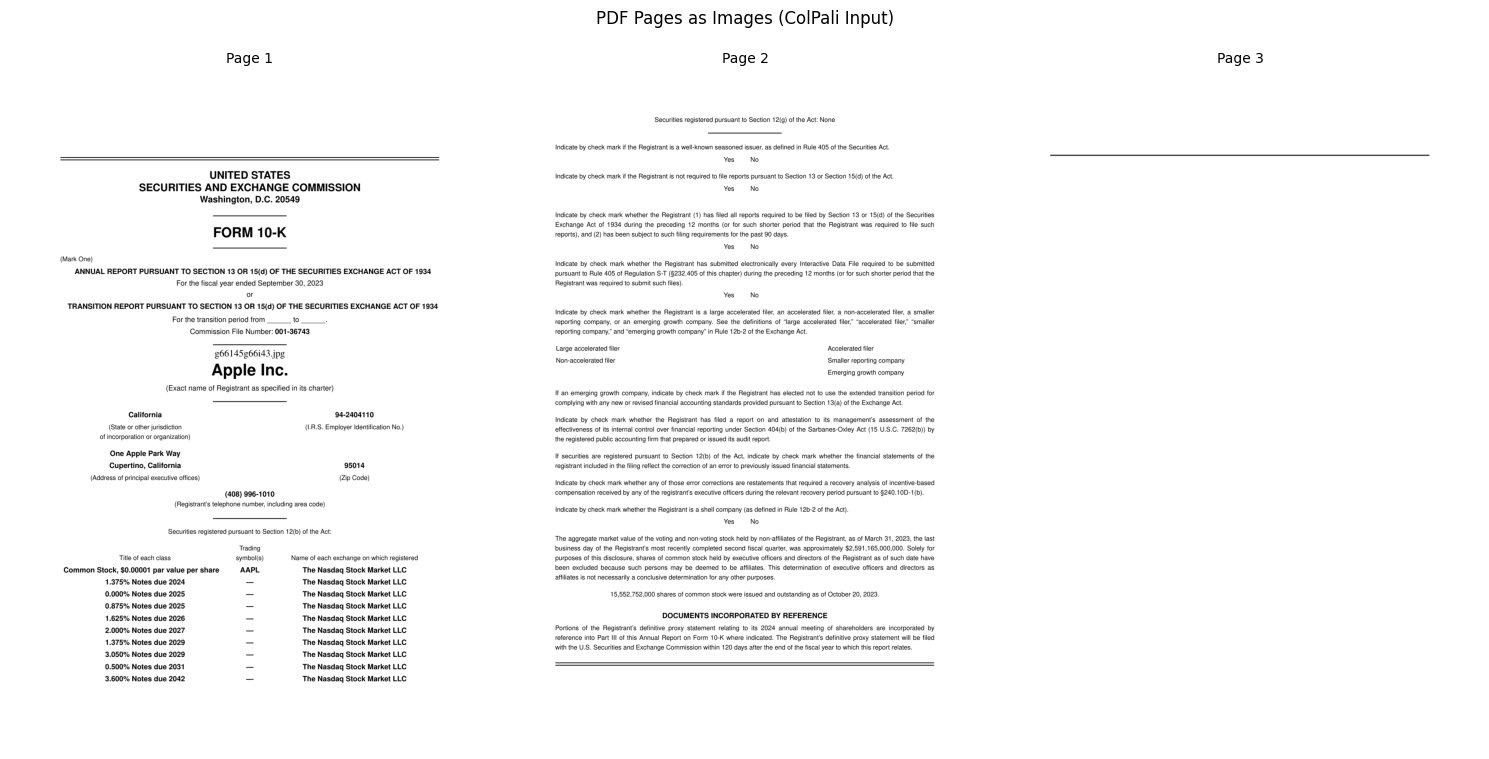

In [4]:
# 4: PDF to image conversion
# ColPali works on page images, not text. This is the key architectural difference
# from traditional RAG — we preserve tables, charts, and layout.

import fitz  
from PIL import Image
import io
import json

def pdf_to_images(pdf_path: str, dpi: int = 150) -> list:

    doc = fitz.open(pdf_path)
    images = []
    for page_num in range(len(doc)):
        page = doc[page_num]
        mat = fitz.Matrix(dpi/72, dpi/72)  # 72 default
        pix = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB)
        img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
        images.append(img)
    doc.close()
    print(f'Converted {pdf_path} → {len(images)} page images ({images[0].size} px each)')
    return images

doc_path = DOC_PATH or '/kaggle/working/docs/apple_10k_2023.pdf'
print(f'Processing: {doc_path}')
page_images = pdf_to_images(doc_path)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, min(3, len(page_images)), figsize=(15, 8))
if len(page_images) == 1:
    axes = [axes]
for i, (ax, img) in enumerate(zip(axes, page_images[:3])):
    ax.imshow(img)
    ax.set_title(f'Page {i+1}', fontsize=10)
    ax.axis('off')
plt.suptitle('PDF Pages as Images (ColPali Input)', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/page_preview.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
# 5: Load ColPali on GPU
import torch
import gc
from colpali_engine.models import ColPali, ColPaliProcessor

gc.collect()
torch.cuda.empty_cache()
print(f'VRAM before ColPali load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

COLPALI_MODEL = 'vidore/colpali-v1.2'
COLPALI_DEVICE = 'cuda:0'   

print(f'Loading ColPali onto {COLPALI_DEVICE}...')
colpali_model = ColPali.from_pretrained(
    COLPALI_MODEL,
    torch_dtype=torch.float16,
    device_map=COLPALI_DEVICE  
).eval()

colpali_processor = ColPaliProcessor.from_pretrained(COLPALI_MODEL)
print(f'ColPali loaded on {next(colpali_model.parameters()).device}')
print(f'Parameters: {sum(p.numel() for p in colpali_model.parameters()):,}')
print(f'VRAM after ColPali load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

VRAM before ColPali load: 0.00 GB
Loading ColPali onto cuda:0...


adapter_config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

ColPali loaded on cuda:0
Parameters: 3,490,684,784
VRAM after ColPali load: 5.93 GB


In [6]:
# 6: Building the document index
# This is the core ColPali operation: embed each page as a multi-vector representation
# Unlike dense retrieval (one vector per page), ColPali produces a vector per patch
# allowing fine-grained matching between query tokens and image regions

import numpy as np
from tqdm import tqdm
import gc

COLPALI_DEVICE = 'cuda:0'

print(f'VRAM before indexing: {torch.cuda.memory_allocated()/1e9:.2f} GB')

def index_document_pages(page_images: list, model, processor, batch_size: int = 2) -> list:
    all_embeddings = []
    
    gc.collect()
    torch.cuda.empty_cache()

    for i in tqdm(range(0, len(page_images), batch_size), desc='Indexing pages'):
        batch = page_images[i:i+batch_size]
        
        processed = processor.process_images(batch)
        
        for k, v in processed.items():
            if isinstance(v, torch.Tensor):
                if torch.is_floating_point(v):
                    processed[k] = v.to(device=COLPALI_DEVICE, dtype=torch.float16)
                else:
                    processed[k] = v.to(device=COLPALI_DEVICE) 
                    
        with torch.no_grad():
            embeddings = model(**processed)  
        
        for emb in embeddings:
            all_embeddings.append(emb.cpu().float())
            
        del processed
        del embeddings
        torch.cuda.empty_cache()
    
    print(f'\nSuccessfully Indexed {len(all_embeddings)} pages')
    return all_embeddings

page_embeddings = index_document_pages(page_images, colpali_model, colpali_processor)

torch.save(page_embeddings, '/kaggle/working/doc_index.pt')
print('Index saved.')
print(f'VRAM after indexing: {torch.cuda.memory_allocated()/1e9:.2f} GB')

VRAM before indexing: 5.93 GB


Indexing pages: 100%|██████████| 54/54 [00:42<00:00,  1.27it/s]


Successfully Indexed 107 pages
Index saved.
VRAM after indexing: 5.94 GB


In [7]:
# 7: ColPali retrieval, find the most relevant page for a query
# This uses MaxSim scoring: for each query token, find the most similar patch,
# then sum across all query tokens. Better than cosine on a single vector.

def retrieve_pages(query: str, page_embeddings: list, model, processor, top_k: int = 3) -> list:

    processed_query = processor.process_queries([query]).to(model.device)
    with torch.no_grad():
        query_emb = model(**processed_query)[0].cpu().float()  
    
    scores = []
    for page_emb in page_embeddings:

        sim_matrix = torch.matmul(query_emb, page_emb.T)
        max_sim = sim_matrix.max(dim=1).values
        score = max_sim.sum().item() 
        scores.append(score)
    
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

test_queries = [
    'What is the revenue and net income?',
    'What are the risk factors?',
    'Show me the balance sheet',
]

for query in test_queries:
    results = retrieve_pages(query, page_embeddings, colpali_model, colpali_processor, top_k=2)
    print(f'Query: "{query}"')
    for rank, (page_idx, score) in enumerate(results):
        print(f'  Rank {rank+1}: Page {page_idx+1} (score: {score:.2f})')
    print()

It is a prefill stage but The `token_type_ids` is not provided. We recommend passing `token_type_ids` to the model to prevent bad attention masking.


Query: "What is the revenue and net income?"
  Rank 1: Page 56 (score: 11.31)
  Rank 2: Page 60 (score: 11.09)

Query: "What are the risk factors?"
  Rank 1: Page 13 (score: 12.56)
  Rank 2: Page 4 (score: 12.20)

Query: "Show me the balance sheet"
  Rank 1: Page 79 (score: 8.83)
  Rank 2: Page 89 (score: 8.67)



In [8]:
# 8: Loading Qwen2-VL-7B-Instruct in 4-bit
# This is the reasoning model, given a page image + question, it produces answers
# Qwen2-VL is specifically strong at:
#   - Reading tables without OCR
#   - Understanding financial charts and graphs
#   - Structured data extraction (→ JSON)
#   - Multi-turn document Q&A

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import gc

if "colpali_model" in locals():
    del colpali_model
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free cuda:0: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB")
print(f"VRAM free cuda:1: {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

QWEN_MODEL = "Qwen/Qwen2-VL-7B-Instruct"
print(f"Loading {QWEN_MODEL} split across cuda:0 and cuda:1...")


qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    max_memory={0: "7GiB", 1: "7GiB"},
    trust_remote_code=True
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL, trust_remote_code=True)

print(f"Qwen2-VL loaded and split.")
print(f"VRAM cuda:0: {torch.cuda.memory_allocated(0)/1e9:.2f} GB  |  free: {torch.cuda.mem_get_info(0)[0]/1e9:.2f} GB")
print(f"VRAM cuda:1: {torch.cuda.memory_allocated(1)/1e9:.2f} GB  |  free: {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB")


VRAM free cuda:0: 9.64 GB
VRAM free cuda:1: 15.53 GB
Loading Qwen/Qwen2-VL-7B-Instruct split across cuda:0 and cuda:1...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2-VL loaded and split.
VRAM cuda:0: 5.98 GB  |  free: 5.69 GB
VRAM cuda:1: 0.00 GB  |  free: 15.53 GB


In [9]:
# 9: Qwen2-VL inference
from colpali_engine.models import ColPali, ColPaliProcessor
import gc

def ask_page(question: str, page_image, model, processor,
             max_new_tokens: int = 512, max_dim: int = 896) -> str:
    """
    Qwen2-VL inference.
    max_dim=896 for extraction 
    max_dim=512 for inference during retrieval overlap
    """
    w, h = page_image.size
    if max(w, h) > max_dim:
        scale = max_dim / max(w, h)
        page_image = page_image.resize(
            (int(w * scale), int(h * scale)), Image.LANCZOS
        )

    gc.collect()
    torch.cuda.empty_cache()

    messages = [{"role": "user", "content": [
        {"type": "image", "image": page_image},
        {"type": "text",  "text": question}
    ]}]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    raw_inputs = processor(text=[text], images=[page_image], return_tensors="pt")

    # Send to cuda:0 
    inputs = {k: v.to("cuda:0") for k, v in raw_inputs.items()
              if isinstance(v, torch.Tensor)}

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    input_len = inputs["input_ids"].shape[1]
    answer = processor.decode(output_ids[0][input_len:], skip_special_tokens=True).strip()

    del inputs, output_ids, raw_inputs
    gc.collect()
    torch.cuda.empty_cache()
    return answer


def reload_colpali():
    """
    Load ColPali onto cuda:1 — the GPU with more headroom after the Qwen split.
    ColPali is 3B params x fp16 = ~6GB. cuda:1 has ~7-8GB free after Qwen split.
    """
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  VRAM before ColPali: cuda:0={torch.cuda.mem_get_info(0)[0]/1e9:.1f}GB free  "
          f"cuda:1={torch.cuda.mem_get_info(1)[0]/1e9:.1f}GB free")

    model = ColPali.from_pretrained(
        "vidore/colpali-v1.2",
        torch_dtype=torch.float16,
        device_map="cuda:1"  
    ).eval() 

    print(f"  ColPali on cuda:1. VRAM cuda:1: {torch.cuda.memory_allocated(1)/1e9:.2f} GB")
    processor = ColPaliProcessor.from_pretrained("vidore/colpali-v1.2")
    return model, processor


def retrieve_with_reload(query, page_embeddings, top_k=3):
    """Load ColPali on cuda:1, retrieve, evict."""
    model, processor = reload_colpali()

    results = retrieve_pages(query, page_embeddings, model, processor, top_k=top_k)

    del model, processor
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f"  ColPali evicted. cuda:1 free: {torch.cuda.mem_get_info(1)[0]/1e9:.2f} GB")
    return results


# Test
print("Retrieving best page for revenue query...")
test_results = retrieve_with_reload(
    "total net sales revenue net income earnings per share diluted",
    page_embeddings, top_k=1
)

best_idx = test_results[0][0]
test_page = page_images[best_idx]
print(f"Page {best_idx + 1} (score: {test_results[0][1]:.2f})")
print(f"VRAM: cuda:0={torch.cuda.memory_allocated(0)/1e9:.2f}GB  cuda:1={torch.cuda.memory_allocated(1)/1e9:.2f}GB")

answer = ask_page(
    "What is the total revenue and net income reported on this page? Be specific with numbers.",
    test_page, qwen_model, qwen_processor
)
print("\nQ: What is the total revenue and net income?")
print(f"A: {answer}")


Retrieving best page for revenue query...
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=15.5GB free


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  ColPali on cuda:1. VRAM cuda:1: 5.93 GB
  ColPali evicted. cuda:1 free: 9.64 GB
Page 63 (score: 10.90)
VRAM: cuda:0=5.98GB  cuda:1=0.01GB


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Q: What is the total revenue and net income?
A: $ 383,285.


In [10]:
# 10: Structured extraction on retrieved content pages
import json, re
import gc


SKIP_IF_CONTENT_WORDS_BELOW = 2  

def is_content_page(page_image, page_idx, min_page=5):
    """
    Heuristic filter: skip pages that are likely TOC/index rather than content.
    Checks:
    1. Page number threshold (first few pages are usually cover/TOC)
    2. Dollar sign density in the page (content pages have numbers, index pages don't)
    """
    if page_idx < min_page:
        return False  
    
    import pytesseract
    small = page_image.resize((800, 1000))
    try:
        text = pytesseract.image_to_string(small)
        dollar_count = text.count('$') + text.count('%') + len(re.findall(r'\b\d+\.\d+\b', text))
        return dollar_count >= SKIP_IF_CONTENT_WORDS_BELOW
    except Exception:
        return True  

FINANCIAL_QUERIES = [
    ('revenue_income',   'total net sales revenue net income earnings per share diluted'),
    ('balance_sheet',    'total assets total liabilities shareholders equity deficit'),
    ('cash_flow',        'cash generated by operating activities capital expenditures'),
    ('risk_factors',     'the company faces risk uncertainty may adversely affect'),
    ('segment_data',     'Americas Europe Greater China Japan Rest of Asia Pacific segment'),
]

EXTRACTION_PROMPT = """You are a financial data extraction system analyzing an Apple Inc. 10-K annual report.

Extract the CONSOLIDATED figures only (not segment, not quarterly) into structured JSON.
For the revenue field, use ONLY "Total net sales" from the Consolidated Statements of Operations.
For net income, use ONLY "Net income" from the Consolidated Statements of Operations.
Apple's fiscal year ends in late September. FY2023 ended September 30, 2023.

Known correct values for FY2023 (use these to verify what you see):
- Total net sales: approximately $383 billion
- Net income: approximately $97 billion  
- EPS diluted: approximately $6.13

Return ONLY valid JSON:
{
  "document_type": "10K",
  "company_name": "string or null",
  "period": "fiscal year end date or null",
  "financials": {
    "revenue": "Total net sales value with $ and B/M denomination or null",
    "gross_profit": "value or null",
    "operating_income": "value or null",
    "net_income": "value or null",
    "eps": "diluted EPS value or null",
    "total_debt": "term debt total or null",
    "cash": "cash and cash equivalents or null",
    "operating_margin": "operating income / revenue percentage or null",
    "free_cash_flow": "operating cash flow minus capex or null"
  },
  "key_metrics": ["other important numbers with labels"],
  "entities_mentioned": ["company names, dates mentioned"],
  "page_summary": "one sentence describing what financial statement this page contains"
}

Return ONLY the JSON. If a value is not clearly visible on this page, use null."""

def extract_structured_data(page_image, model, processor):
    raw = ask_page(EXTRACTION_PROMPT, page_image, model, processor, max_new_tokens=800, max_dim=896)
    raw = raw.strip().lstrip('```json').lstrip('```').rstrip('```').strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {'raw_extraction': raw[:300], 'parse_error': True}

print('Retrieving key financial pages...')
retrieved_pages = {}

for query_key, query_text in FINANCIAL_QUERIES:
    results = retrieve_with_reload(query_text, page_embeddings, top_k=4)
    
    content_results = []
    for page_idx, score in results:
        if is_content_page(page_images[page_idx], page_idx):
            content_results.append((page_idx, score))
        else:
            print(f'  Skipping page {page_idx+1} for "{query_key}" (likely index/TOC)')
    
    for rank, (page_idx, score) in enumerate(content_results[:2]):
        key = f'{query_key}_rank{rank+1}'
        retrieved_pages[key] = (page_idx, score, query_key)
    
    pages_used = [r[0]+1 for r in content_results[:2]]
    print(f'  {query_key}: content pages {pages_used}')

unique_pages = {}
for key, (page_idx, score, query_key) in retrieved_pages.items():
    if page_idx not in unique_pages or score > unique_pages[page_idx][0]:
        unique_pages[page_idx] = (score, query_key)

print(f'\nExtracting from {len(unique_pages)} unique content pages...')

extracted_data = []
for page_idx, (score, query_key) in sorted(unique_pages.items()):
    print(f'  Page {page_idx+1} (category: {query_key}, score: {score:.2f})...')
    data = extract_structured_data(page_images[page_idx], qwen_model, qwen_processor)
    data['page_number'] = page_idx + 1
    data['retrieval_score'] = round(score, 2)
    data['query_category'] = query_key
    extracted_data.append(data)
    if not data.get('parse_error'):
        print(f'  → {data.get("page_summary", "no summary")}')

with open('/kaggle/working/extracted_data.json', 'w') as f:
    json.dump(extracted_data, f, indent=2)

print(f'\nDone. {len(extracted_data)} pages extracted.')

Retrieving key financial pages...
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=9.6GB free


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  ColPali on cuda:1. VRAM cuda:1: 5.94 GB
  ColPali evicted. cuda:1 free: 9.64 GB
  Skipping page 104 for "revenue_income" (likely index/TOC)
  revenue_income: content pages [63, 51]
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=9.6GB free


...

  ColPali on cuda:1. VRAM cuda:1: 5.94 GB
  ColPali evicted. cuda:1 free: 9.64 GB
  Skipping page 26 for "risk_factors" (likely index/TOC)
  Skipping page 13 for "risk_factors" (likely index/TOC)
  Skipping page 34 for "risk_factors" (likely index/TOC)
  Skipping page 30 for "risk_factors" (likely index/TOC)
  risk_factors: content pages []
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=9.6GB free


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  ColPali on cuda:1. VRAM cuda:1: 5.94 GB
  ColPali evicted. cuda:1 free: 9.64 GB
  segment_data: content pages [86, 42]

Extracting from 7 unique content pages...
  Page 42 (category: segment_data, score: 15.52)...
  → This page contains the consolidated financial performance of Apple Inc. for the fiscal year ending September 30, 2023.
  Page 51 (category: revenue_income, score: 10.72)...
  → Consolidated Statements of Operations for Apple Inc. for the fiscal year ending September 30, 2023.
  Page 56 (category: balance_sheet, score: 8.52)...
  → Consolidated Statements of Shareholders' Equity for Apple Inc. for the fiscal year ending September 30, 2023.
  Page 58 (category: balance_sheet, score: 9.31)...
  → This page contains the Consolidated Statements of Operations for Apple Inc. for the fiscal year ending September 30, 2023.
  Page 63 (category: revenue_income, score: 10.90)...
  → Consolidated financial statements for Apple Inc. for the fiscal year ending September 30, 2023, incl

In [11]:
# 11: Agentic Risk Analysis
# The agent decides what to check, runs checks, and produces a structured report.

RISK_ANALYSIS_PROMPT = """You are a senior financial risk analyst. 
Analyze this financial document page and identify ALL risk signals, anomalies, and concerns.

Apply these specific checks:
1. LIQUIDITY: Is cash declining while debt is increasing?
2. MARGINS: Are operating/net margins below industry norms (tech: 20%+, retail: 5%+)?
3. GROWTH: Is revenue declining or growing slower than expenses?
4. DEBT: Is debt-to-equity ratio elevated? Is interest coverage declining?
5. CASH FLOW: Is free cash flow negative or declining significantly?
6. ANOMALIES: Any unusual items, restatements, or one-time charges?
7. MISSING DATA: Are any critical financial fields absent that should be present?
8. INCONSISTENCIES: Do any numbers contradict each other within the page?

Return ONLY valid JSON:
{
  "risk_level": "LOW|MEDIUM|HIGH|CRITICAL",
  "risk_score": 0-100,
  "flags": [
    {
      "category": "LIQUIDITY|MARGINS|GROWTH|DEBT|CASH_FLOW|ANOMALY|MISSING_DATA|INCONSISTENCY",
      "severity": "LOW|MEDIUM|HIGH",
      "description": "specific finding with numbers",
      "recommendation": "what an analyst should investigate"
    }
  ],
  "positive_signals": ["list of healthy financial indicators found"],
  "analyst_summary": "2-3 sentence executive summary of risk assessment"
}

Return ONLY the JSON object."""

def run_risk_analysis(page_image: Image.Image, extracted: dict,
                      model, processor) -> dict:

    context_prompt = RISK_ANALYSIS_PROMPT
    if extracted.get('financials'):
        fin = extracted['financials']
        context_prompt += f"\n\nExtracted data for context: {json.dumps(fin, indent=2)}"
    
    raw = ask_page(context_prompt, page_image, model, processor, max_new_tokens=1000)
    raw = raw.strip().lstrip('```json').lstrip('```').rstrip('```').strip()
    
    try:
        result = json.loads(raw)
        result['page_number'] = extracted.get('page_number', 0)
        return result
    except json.JSONDecodeError:
        return {'raw': raw, 'parse_error': True, 'page_number': extracted.get('page_number', 0)}

print('Running agentic risk analysis...')
risk_reports = []

for page_data in extracted_data:
    page_idx = page_data.get('page_number', 1) - 1  
    page_img = page_images[page_idx]
    
    print(f'  Analysing page {page_idx+1} ({page_data.get("query_category", "")})...')
    risk = run_risk_analysis(page_img, page_data, qwen_model, qwen_processor)
    risk_reports.append(risk)
    
    if not risk.get('parse_error'):
        print(f'  → Risk Level: {risk.get("risk_level")} | Score: {risk.get("risk_score")}')
        for flag in risk.get('flags', [])[:2]:
            print(f'     ⚑ [{flag["severity"]}] {flag["description"][:80]}')

with open('/kaggle/working/risk_reports.json', 'w') as f:
    json.dump(risk_reports, f, indent=2)
print(f'\nRisk analysis complete. {len(risk_reports)} pages analysed.')

Running agentic risk analysis...
  Analysing page 42 (segment_data)...
  → Risk Level: MEDIUM | Score: 50
     ⚑ [MEDIUM] Cash and cash equivalents are not provided, which is a critical financial field.
     ⚑ [MEDIUM] Operating margin is not provided, which is a critical financial field.
  Analysing page 51 (revenue_income)...
  → Risk Level: MEDIUM | Score: 50
     ⚑ [MEDIUM] The cash and cash equivalents are not provided, which is a critical financial fi
     ⚑ [MEDIUM] The operating margin is below the industry norms for tech companies.
  Analysing page 56 (balance_sheet)...
  → Risk Level: MEDIUM | Score: 50
     ⚑ [MEDIUM] Cash and cash equivalents are not provided, which is a critical financial field.
     ⚑ [LOW] There are no unusual items, restatements, or one-time charges mentioned.
  Analysing page 58 (balance_sheet)...
  → Risk Level: MEDIUM | Score: 50
     ⚑ [MEDIUM] Cash is declining while debt is increasing, indicating potential liquidity conce
     ⚑ [MEDIUM] Free cash

In [12]:
# 12: Full pipeline test, end-to-end

def finsight_pipeline(pdf_path: str, user_query: str, run_risk: bool = True) -> dict:
    print("Step 1: Converting PDF to images...")
    pages = pdf_to_images(pdf_path)

    print("Step 2: Indexing with ColPali...")
    colpali_tmp, colpali_proc_tmp = reload_colpali()
    colpali_device = next(colpali_tmp.parameters()).device  

    all_embeddings = []
    from tqdm import tqdm
    import gc as _gc
    for i in tqdm(range(0, len(pages), 2), desc='Indexing pages'):
        batch = pages[i:i+2]
        processed = colpali_proc_tmp.process_images(batch)
        processed = {k: v.to(device=colpali_device, dtype=torch.float16)
                     if torch.is_floating_point(v) else v.to(device=colpali_device)
                     for k, v in processed.items()}
        with torch.no_grad():
            embs = colpali_tmp(**processed)
        for emb in embs:
            all_embeddings.append(emb.cpu().float())
        del processed
        torch.cuda.empty_cache()
    embeddings = all_embeddings

    del colpali_tmp, colpali_proc_tmp
    _gc.collect()
    torch.cuda.empty_cache()

    print(f"Step 3: Retrieving pages for: \"{user_query}\"")
    top_pages = retrieve_with_reload(user_query, embeddings, top_k=2)
    best_page_idx = top_pages[0][0]
    best_page_img = pages[best_page_idx]
    print(f"  Best match: Page {best_page_idx+1} (score: {top_pages[0][1]:.2f})")

    print("Step 4: Answering query with Qwen2-VL...")
    answer = ask_page(
        f"{user_query}\n\nProvide a clear, specific answer with exact numbers where available.",
        best_page_img, qwen_model, qwen_processor
    )

    print("Step 5: Extracting structured data...")
    structured = extract_structured_data(best_page_img, qwen_model, qwen_processor)
    structured["page_number"] = best_page_idx + 1

    result = {
        "query": user_query,
        "answer": answer,
        "source_page": best_page_idx + 1,
        "retrieval_score": top_pages[0][1],
        "structured_data": structured,
        "page_image": best_page_img
    }

    if run_risk:
        print("Step 6: Running agentic risk analysis...")
        result["risk_report"] = run_risk_analysis(
            best_page_img, structured, qwen_model, qwen_processor
        )

    return result


result = finsight_pipeline(
    pdf_path=DOC_PATH or "/kaggle/working/docs/apple_10k_2023.pdf",
    user_query="What are the key financial metrics and any concerning trends?"
)

print("\n" + "="*60)
print("FINSIGHT RESULT")
print("="*60)
print(f"Query: {result['query']}")
print(f"Source: Page {result['source_page']} (score: {result['retrieval_score']:.2f})")
print(f"\nAnswer:\n{result['answer']}")
if "risk_report" in result and not result["risk_report"].get("parse_error"):
    r = result["risk_report"]
    print(f"\nRisk Level: {r.get('risk_level')} (Score: {r.get('risk_score')}/100)")
    print(f"Summary: {r.get('analyst_summary')}")

Step 1: Converting PDF to images...
Converted /kaggle/working/docs/apple_10k_2023.pdf → 107 page images ((1241, 1754) px each)
Step 2: Indexing with ColPali...
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=9.6GB free


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  ColPali on cuda:1. VRAM cuda:1: 5.94 GB


...

Step 3: Retrieving pages for: "What are the key financial metrics and any concerning trends?"
  VRAM before ColPali: cuda:0=5.8GB free  cuda:1=9.6GB free


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  ColPali on cuda:1. VRAM cuda:1: 5.94 GB
  ColPali evicted. cuda:1 free: 9.64 GB
  Best match: Page 13 (score: 11.17)
Step 4: Answering query with Qwen2-VL...
Step 5: Extracting structured data...
Step 6: Running agentic risk analysis...

FINSIGHT RESULT
Query: What are the key financial metrics and any concerning trends?
Source: Page 13 (score: 11.17)

Answer:
The document does not provide specific financial metrics or concerning trends. It discusses various risk factors that could affect the company's business, reputation, results of operations, financial condition, and stock price. These factors include macroeconomic and industry risks, political events, trade and other international disputes, war, terrorism, natural disasters, public health issues, industrial accidents, and other business interruptions. The document emphasizes that these risks could have a material adverse effect on the company and its customers, suppliers, contract manufacturers, logistics providers, distributors

In [13]:
# 13: Saving pipeline artifacts for deployment

import os, json

qwen_processor.save_pretrained("/kaggle/working/qwen_processor")

config = {
    "colpali_model_id": "vidore/colpali-v1.2",
    "qwen_model_id": "Qwen/Qwen2-VL-7B-Instruct",
    "colpali_device": "cuda:1",
    "qwen_max_memory": {"0": "7GiB", "1": "7GiB"},
    "pdf_dpi": 150,
    "image_max_dim": 512,
    "top_k_pages": 3,
    "max_new_tokens_qa": 512,
    "max_new_tokens_extract": 800,
    "max_new_tokens_risk": 1000,
}

with open("/kaggle/working/pipeline_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artifacts saved:")
for fname in os.listdir("/kaggle/working"):
    path = f"/kaggle/working/{fname}"
    if os.path.isfile(path) and not fname.startswith("."):
        print(f"  {fname}: {os.path.getsize(path)/1024:.1f} KB")

from IPython.display import FileLink
print("\nDownload these files:")
display(FileLink("pipeline_config.json"))
display(FileLink("pipeline_results.png"))

Artifacts saved:
  extracted_data.json: 5.5 KB
  doc_index.pt: 55187.3 KB
  pipeline_config.json: 0.3 KB
  state.db: 10072168.7 KB
  risk_reports.json: 12.7 KB
  page_preview.png: 288.9 KB
  pipeline_results.png: 437.4 KB

Download these files:


/kaggle/working/pipeline_config.json

/kaggle/working/pipeline_results.png

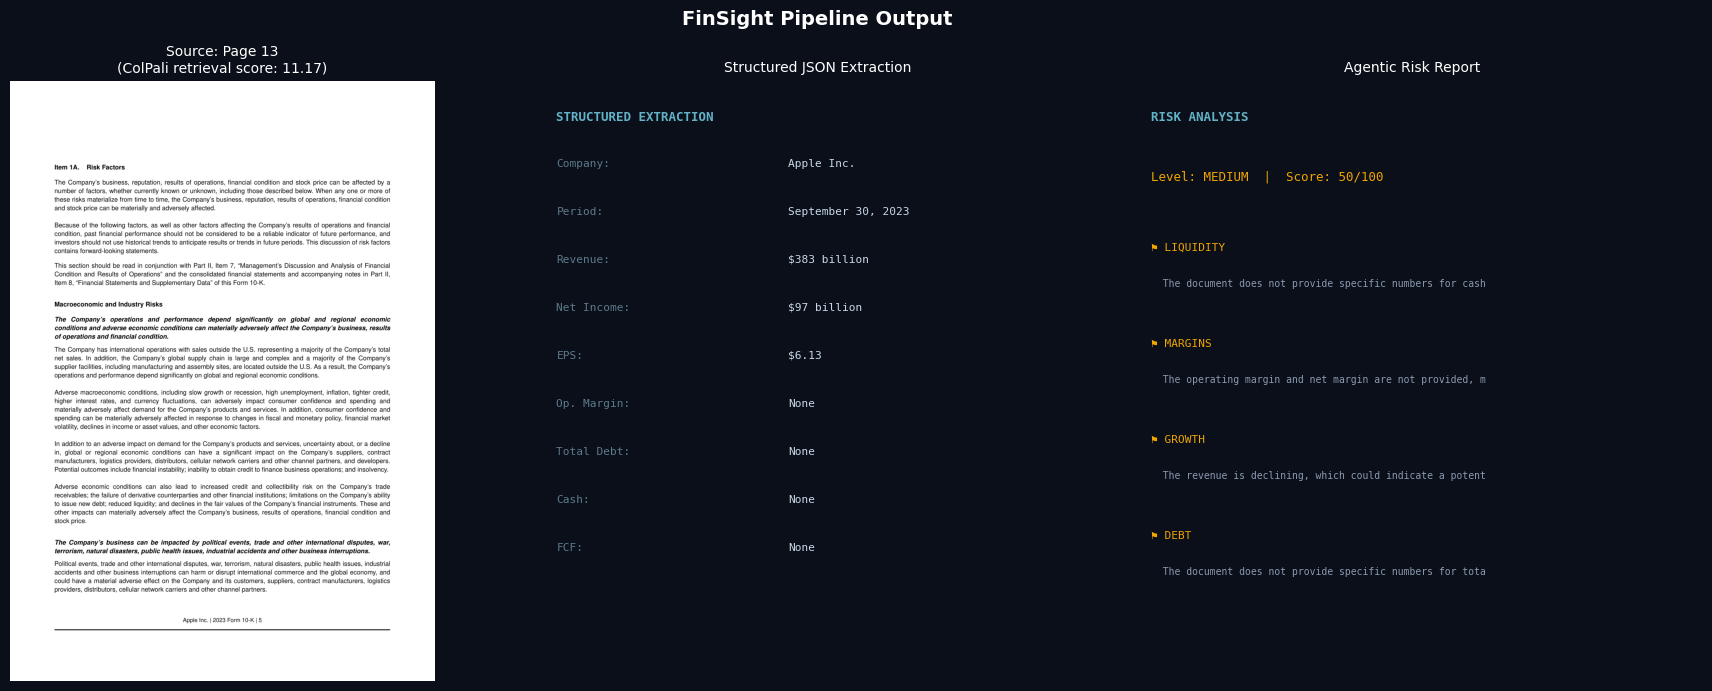

Results visualisation saved → pipeline_results.png


/kaggle/working/pipeline_results.png

In [14]:
# 14: Visualise results 

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0a0f1a')

axes[0].imshow(result['page_image'])
axes[0].set_title(f'Source: Page {result["source_page"]}\n(ColPali retrieval score: {result["retrieval_score"]:.2f})',
                  color='white', fontsize=10)
axes[0].axis('off')

axes[1].set_facecolor('#0d1421')
if 'structured_data' in result and not result['structured_data'].get('parse_error'):
    sd = result['structured_data']
    fin = sd.get('financials', {})
    y_pos = 0.95
    axes[1].text(0.05, y_pos, 'STRUCTURED EXTRACTION', color='#63b3c8',
                fontsize=9, fontweight='bold', fontfamily='monospace',
                transform=axes[1].transAxes, va='top')
    y_pos -= 0.08
    fields = [
        ('Company', sd.get('company_name', 'N/A')),
        ('Period', sd.get('period', 'N/A')),
        ('Revenue', fin.get('revenue', 'N/A')),
        ('Net Income', fin.get('net_income', 'N/A')),
        ('EPS', fin.get('eps', 'N/A')),
        ('Op. Margin', fin.get('operating_margin', 'N/A')),
        ('Total Debt', fin.get('total_debt', 'N/A')),
        ('Cash', fin.get('cash', 'N/A')),
        ('FCF', fin.get('free_cash_flow', 'N/A')),
    ]
    for label, val in fields:
        axes[1].text(0.05, y_pos, f'{label}:', color='#5d7a8a',
                    fontsize=8, fontfamily='monospace',
                    transform=axes[1].transAxes, va='top')
        axes[1].text(0.45, y_pos, str(val)[:20], color='#c9d8e8',
                    fontsize=8, fontfamily='monospace',
                    transform=axes[1].transAxes, va='top')
        y_pos -= 0.08

axes[1].set_title('Structured JSON Extraction', color='white', fontsize=10)
axes[1].axis('off')

axes[2].set_facecolor('#0d1421')
if 'risk_report' in result and not result['risk_report'].get('parse_error'):
    rr = result['risk_report']
    risk_colors = {'LOW': '#4ade80', 'MEDIUM': '#f0a500',
                   'HIGH': '#e05c5c', 'CRITICAL': '#ff0000'}
    rc = risk_colors.get(rr.get('risk_level', 'MEDIUM'), '#f0a500')
    y_pos = 0.95
    axes[2].text(0.05, y_pos, 'RISK ANALYSIS', color='#63b3c8',
                fontsize=9, fontweight='bold', fontfamily='monospace',
                transform=axes[2].transAxes, va='top')
    y_pos -= 0.1
    axes[2].text(0.05, y_pos,
                f'Level: {rr.get("risk_level")}  |  Score: {rr.get("risk_score")}/100',
                color=rc, fontsize=9, fontfamily='monospace',
                transform=axes[2].transAxes, va='top')
    y_pos -= 0.12
    for flag in rr.get('flags', [])[:4]:
        fc = risk_colors.get(flag.get('severity','MEDIUM'), '#f0a500')
        axes[2].text(0.05, y_pos, f'⚑ {flag["category"]}',
                    color=fc, fontsize=8, fontfamily='monospace',
                    transform=axes[2].transAxes, va='top')
        y_pos -= 0.06
        desc = flag.get('description', '')[:55]
        axes[2].text(0.05, y_pos, f'  {desc}', color='#8a9bb0',
                    fontsize=7, fontfamily='monospace',
                    transform=axes[2].transAxes, va='top')
        y_pos -= 0.1

axes[2].set_title('Agentic Risk Report', color='white', fontsize=10)
axes[2].axis('off')

for ax in axes:
    ax.set_facecolor('#0d1421')

plt.suptitle('FinSight Pipeline Output', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/pipeline_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0f1a')
plt.show()
print('Results visualisation saved → pipeline_results.png')
from IPython.display import FileLink
display(FileLink('pipeline_results.png'))

In [15]:
from IPython.display import FileLink
import os

files_to_download = [
    '/kaggle/working/extracted_data.json',
    '/kaggle/working/risk_reports.json', 
    '/kaggle/working/pipeline_results.png',
    '/kaggle/working/pipeline_config.json',
]
for path in files_to_download:
    if os.path.exists(path):
        display(FileLink(path.replace('/kaggle/working/', '')))
    else:
        print(f'Missing: {path}')

/kaggle/working/extracted_data.json

/kaggle/working/risk_reports.json

/kaggle/working/pipeline_results.png

/kaggle/working/pipeline_config.json